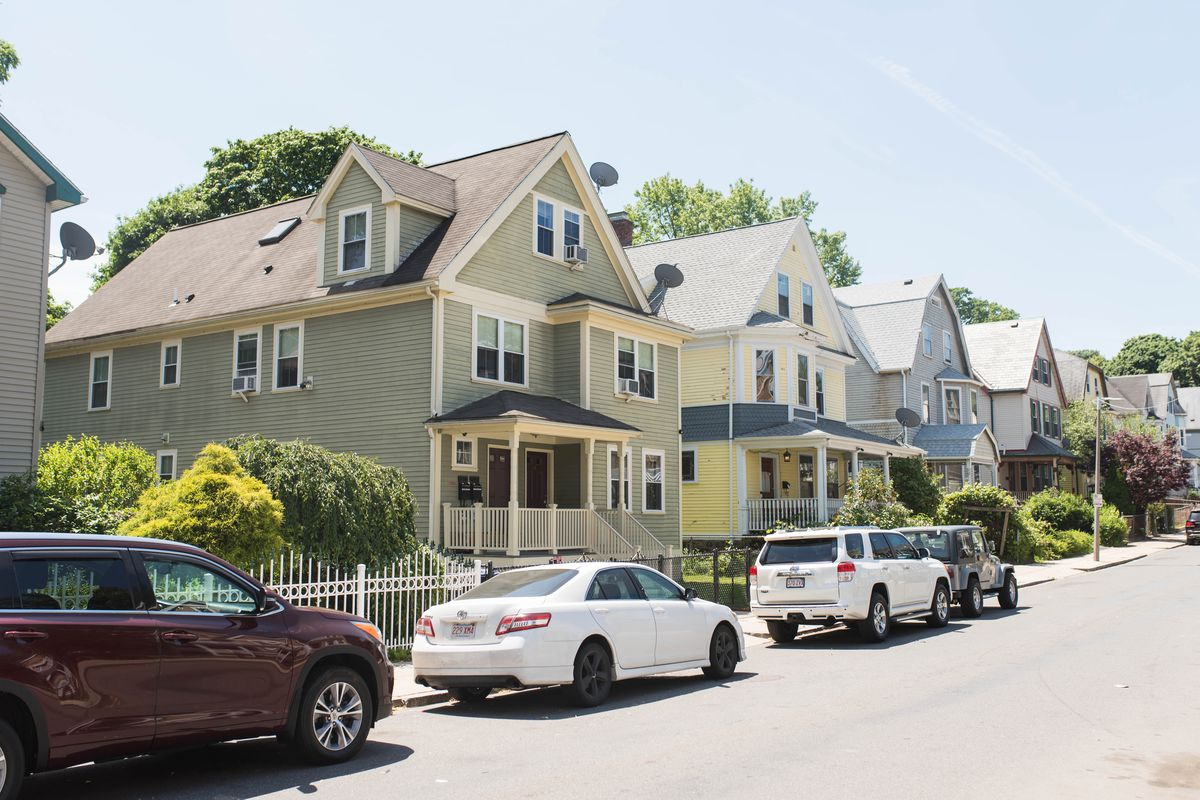

# Uy Narxini Bashorat Qilish – Multivariable Linear Regression

**Loyiha tavsifi:**

Bu loyiha uy narxini oldindan aytish (predict) qilishga qaratilgan. Bashorat uy maydoni, yotoq xonalari soni, mebellanganligi, asosiy yo‘lga yaqinligi kabi omillarga asoslanadi. Dataset kichik bo‘lsa-da, murakkabligi multikolinearlik (ba’zi ustunlar bir-biriga kuchli bog‘liq) tufayli oshadi. Ushbu murakkablikni yengib, sifatli prediktiv model qurish imkoniyatini sinab ko‘ramiz.

**Maqsadlar:**

+ Datasetni tushunish va kerak bo‘lsa tozalash

+ Yagona yoki bir nechta feature asosida regression modellari qurish

+ Modellarni baholash va ularning R², RMSE kabi ko‘rsatkichlarini solishtirish

**Minnatdorchilik:**

+ Harrison, D. va Rubinfeld, D.L. (1978). Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.

+ Belsley D.A., Kuh, E. va Welsch, R.E. (1980). Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley


## Setup: Importing Required Libraries

Avvalo, ishlash uchun zarur kutubxonalarni import qilamiz.

In [3]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Overview

Birinchi qadamimiz – datasetni yuklab, uning tuzilishini va ba'zi dastlabki qiymatlarni ko‘rib chiqish.  
Bu orqali ma’lumot turlarini, null qiymatlarni va dastlabki qatorlarni tekshiramiz.

In [4]:
df = pd.read_csv('Housing.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Checking for Missing Values

Datasetda NaN (missing) qiymatlar mavjudligini tekshiramiz.  
Agar NaN qiymatlar bo'lsa, ularni tozalash yoki to‘ldirish kerak bo‘ladi.

In [5]:
num_examples_with_nan = df.isnull().any(axis=1).sum()
print(f"Nan mavjud bo'lgan row soni: {num_examples_with_nan}")

Nan mavjud bo'lgan row soni: 0


## 3. Identifying Categorical Features

Ma'lumotlarni tahlil qilishda, categorical (toifaviy) ustunlarni aniqlash muhim.  
Shu ustunlar keyinchalik **encoding** qilinadi, chunki regression modeli faqat numeric qiymatlar bilan ishlaydi.  

Eslatma: `furnishingstatus` ustuni maxsus sabab bilan alohida qoldirildi.

In [6]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols = [col for col in categorical_cols if col != 'furnishingstatus']
categorical_cols

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea']

## 4. Encoding Categorical Features

Regression modeli faqat numeric qiymatlar bilan ishlaydi, shuning uchun categorical ustunlarni numericga aylantiramiz:

- `yes/no` qiymatlar → 1/0  
- `furnishingstatus`:
    - `furnished` → 1  
    - `semi-furnished` → 0.5  
    - `unfurnished` → 0

Bu transformatsiya keyingi **model building** bosqichi uchun zarur.

In [7]:
for i in categorical_cols:
  df[i] = df[i].map({'yes':1, 'no':0})
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished':1, 'semi-furnished':0.5, 'unfurnished':0})

In [8]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,0.5
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,0.5
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0.0
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,1.0
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0.0


## 5. Defining Features (X) and Target (y)

Endi model qurish uchun **input features** va **target variable**ni ajratamiz:

- `X` → barcha ustunlar, lekin `price` tashqari (input features)
- `y` → `price` ustuni (target variable)

Bu qadam model training uchun zarur.

In [9]:
X = df.drop('price', axis=1)
y = df['price']
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,7420,4,1,2,1,1,1,0,1,2,0,1.0


## 6. Building & Training the Linear Regression Model

Linear Regression modeli qurildi va **fit** qilinmoqda:

- Model `X` features bilan `y` targetni o‘rganadi
- Bu bosqichda modelning **coefficients** va **intercept** aniqlanadi
- Keyinchalik bu model yordamida price ni prediktsiya qilamiz

In [10]:
model = linear_model.LinearRegression()
model.fit(X,y)
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [2.43906887e+02 1.19474386e+05 9.88888287e+05 4.50391518e+05
 4.23100741e+05 2.98030507e+05 3.57926360e+05 8.72936027e+05
 8.53633595e+05 2.79785637e+05 6.47055599e+05 4.26375563e+05]
Model Intercept: -324509.0498633785


## 7. Feature Importance Visualization

Linear Regression modelidagi coefficients har bir feature ning target (price) ga ta’sirini ko‘rsatadi.  
Bu vizualizatsiya orqali qaysi features eng katta ta’sirga ega ekanligini bir qarashda ko‘rish mumkin.

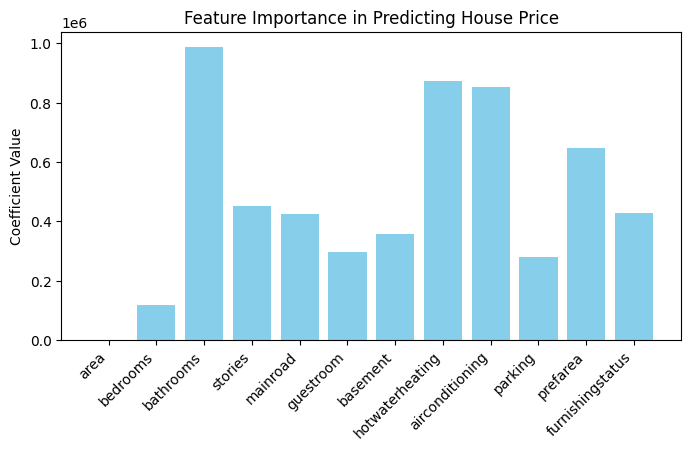

In [11]:

feature_names = X.columns

coefficients = model.coef_

plt.figure(figsize=(8,4))
plt.bar(feature_names, coefficients, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Coefficient Value")
plt.title("Feature Importance in Predicting House Price")
plt.show()

## Predicting Price for a New House

Yangi uyimiz quyidagi features ga ega:

| Feature             | Value |
|--------------------|-------|
| Area (sq ft)        | 10230 |
| Bedrooms            | 6     |
| Bathrooms           | 2     |
| Stories             | 3     |
| Near Main Road      | Yes (1) |
| Guest Room          | Yes (1) |
| Basement            | No (0) |
| Hot Water Heating   | No (0) |
| Air Conditioning    | Yes (1) |
| Parking             | 2     |
| Preferred Area      | Yes (1) |
| Furnishing Status   | Furnished (1) |

Modelimiz bu ma’lumotlar asosida **uy narxini prediktsiya qiladi**.

In [12]:

new_house = [[10230,6,2,3,1,1,0,0,1,2,1,1]]

predicted_price = model.predict(new_house)
print(f"Predicted Price for the given house: {predicted_price[0]:,.2f}")

Predicted Price for the given house: 9,424,223.13


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 9. Actual vs Predicted Prices

Bu scatter plot yordamida modelning **performance**ini vizual tarzda ko‘rish mumkin:

- Har bir ko‘k nuqta → bitta uy uchun **predicted vs actual price**  
- Qizil chiziq → ideal chiziq (predicted = actual)  
- Kulrang chiziqlar → har bir nuqtaning **xatolik (error)**ini ko‘rsatadi  

Shu grafik orqali qaysi uylar model uchun yaxshi prognozlanganini va qaysi uylar katta xatolik bilan prognozlanganini ko‘rish mumkin.

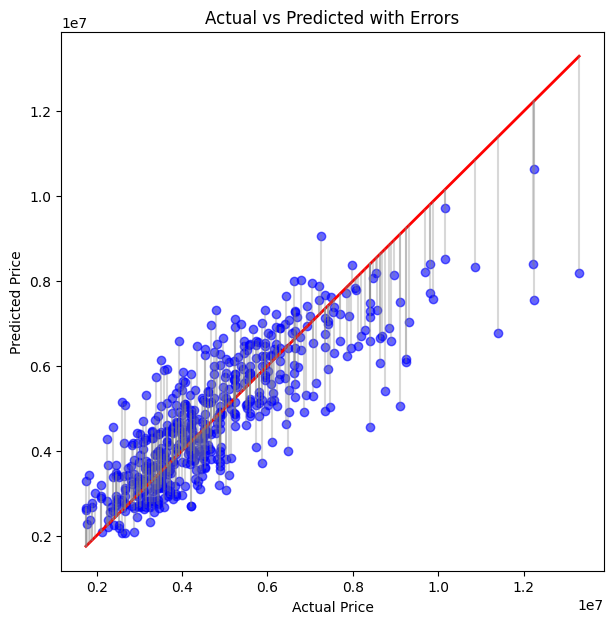

In [13]:
y_pred = model.predict(X)

plt.figure(figsize=(7,7))


plt.scatter(y, y_pred, color='blue', alpha=0.6)


min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red',
         linewidth=2)


for i in range(len(y)):
    plt.plot([y.iloc[i], y.iloc[i]],
             [y.iloc[i], y_pred[i]],
             color='gray',
             alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted with Errors")
plt.show()

## 10. Modelni Baholash

Modelning qanchalik yaxshi ishlashini raqamlar bilan baholaymiz:

- **R² score** → modelning tushuntirish kuchi, ya'ni features price ni qancha foiz tushuntiradi  
- **RMSE** → model prediktsiyasidagi xatoliklarning o‘rtacha kvadrat ildizi  

Shuningdek, Actual vs Predicted scatter plot orqali xatoliklarni vizual tarzda ko‘rish mumkin.

In [14]:
y1 = model.predict(X)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

r2 = r2_score(y, y1)
rmse = np.sqrt(mean_squared_error(y, y1))

print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:,.2f}")

R² score: 0.6801
RMSE: 1,056,995.06


## 11. Model Performance Summary

Quyidagi jadvalda Linear Regression modelining asosiy ko‘rsatkichlari keltirilgan:

- **R² score** → model tushuntiruvchi kuchi, ya'ni features price ning qanchalik foizini tushuntiradi. Yuqori qiymat → model yaxshiroq fit qilgan.  
- **RMSE** → model prediktsiyalaridagi o‘rtacha xatolik, ya'ni predicted price bilan actual price orasidagi farqning kvadrat ildizlari o‘rtachasi. Past qiymat → model prediktsiyasi aniqroq.

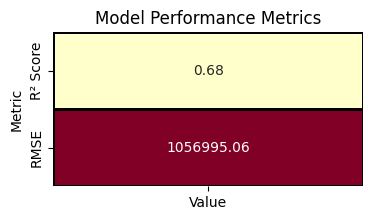

In [15]:
metrics = pd.DataFrame({
    "Metric": ["R² Score", "RMSE"],
    "Value": [r2, rmse]
}).set_index("Metric")

plt.figure(figsize=(4,2))
sns.heatmap(metrics, annot=True,
            fmt=".2f", cmap="YlOrRd",
            cbar=False, linewidths=1,
            linecolor='black')
plt.title("Model Performance Metrics")
plt.show()

## 12. Model Performance Interpretation

Linear Regression modelining asosiy baholash ko‘rsatkichlari quyidagicha:

| Metric  | Value        |
|---------|-------------|
| R²      | 0.68        |  
| RMSE    | 1,056,995   |

Model datasetdagi uy narxining 68% ni tushuntiradi. Bu shuni bildiradiki, model asosiy tendensiyalarni ushlab oladi, lekin barcha variance’ni tushuntira olmaydi.
O‘rtacha prediktsiya xatoligi taxminan 1 million so‘m atrofida. Ba’zi uylar uchun model prediktsiya narxi actual price’dan sezilarli farq qilishi mumkin.

**Xulosa:**  
- Model ishlayapti, lekin hali prediktsiya aniq emas.  
- Sabablari: multikolinearlik, kichik dataset, ba’zi feature’larning murakkab ta’siri.  
- Keyingi qadamlar: feature selection / dimensionality reduction, regularization (Ridge/Lasso), yoki datasetni kattalashtirish.